## NBA Shot Selection Prediction 

## Business Understanding

Kobe Bryant, one of the greatest basketball players in history, played 20 seasons with the Los Angeles Lakers. Over his career, he took thousands of shots in varying game situations — from buzzer-beaters to playoff clutch moments. Understanding the context and success rate of these shots can offer powerful insights for sports analysts, coaches, and players.

In this project, we analyze the **complete dataset of Kobe Bryant’s shot attempts** to identify patterns that lead to successful or missed shots. The ultimate goal is to **build a machine learning model** that can predict whether a shot is likely to be successful based on game and shot conditions.

##  Dataset Overview

The dataset contains detailed information about **every field goal attempt Kobe Bryant took** during his 20-year NBA career. It includes features like:

- **Game context**: period, time remaining, opponent, playoffs
- **Shot context**: location (x, y, lat, lon), shot distance, shot type, zone
- **Game info**: season, matchup, home/away
- **Target variable**: `shot_made_flag` (0 or 1)

> Total rows: ~30,000 | Features: 25+ | Domain: **Sports Analytics**


## What is `shot_made_flag`?

- **`shot_made_flag` = 1**: The shot was **made** (successful)
- **`shot_made_flag` = 0**: The shot was **missed**
- This is the **target variable** for prediction.

## Problem Type

This is a **Supervised Binary Classification Problem**.

We will use machine learning algorithms to **predict whether a shot will be made (1) or missed (0)** based on the features describing the shot and the game situation.

## The objective is to:
- Analyze Kobe Bryant’s shot data using visual analytics.
- Help stakeholders understand shot selection patterns.
- Predict the probability of a successful shot using machine learning.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = 'notebook' 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import shap

In [2]:
#loading the dataset
data = pd.read_csv('C:/Users/arbaj/Projects/NBA Shot Predictions/data/data.csv')

In [3]:
#first 5 rows of the data
data.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


In [4]:
#last 5 rows of the data
data.tail()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
30692,Jump Shot,Jump Shot,397,49900088,33.9963,1,48,-118.2688,6,4,...,2PT Field Goal,Center(C),In The Paint (Non-RA),Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30693
30693,Tip Shot,Tip Shot,398,49900088,34.0443,0,0,-118.2698,6,4,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30694
30694,Running Jump Shot,Jump Shot,426,49900088,33.8783,-134,166,-118.4038,3,4,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30695
30695,Jump Shot,Jump Shot,448,49900088,33.7773,31,267,-118.2388,2,4,...,3PT Field Goal,Center(C),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30696
30696,Jump Shot,Jump Shot,471,49900088,33.9723,1,72,-118.2688,0,4,...,2PT Field Goal,Center(C),In The Paint (Non-RA),Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30697


In [5]:
#basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [6]:
# Drop rows where target is null
data = data.dropna(subset=['shot_made_flag'])

# Convert shot_made_flag to int for clear coloring
data['shot_made_flag'] = data['shot_made_flag'].astype(int)


In [7]:
#statistical information
data.describe()

,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id
count,25697.000000,2.569700e+04,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,25697.000000,2.569700e+04,25697.000000
mean,249.348679,2.474109e+07,33.953043,7.148422,91.257345,-118.262652,4.886796,2.520800,0.146243,28.311554,13.457096,0.446161,1.610613e+09,15328.166946
std,149.778520,7.738108e+06,0.088152,110.073147,88.152106,0.110073,3.452475,1.151626,0.353356,17.523392,9.388725,0.497103,0.000000e+00,8860.462397
min,2.000000,2.000001e+07,33.253300,-250.000000,-44.000000,-118.519800,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.610613e+09,2.000000
25%,111.000000,2.050006e+07,33.884300,-67.000000,4.000000,-118.336800,2.000000,1.000000,0.000000,13.000000,5.000000,0.000000,1.610613e+09,7646.000000
50%,253.000000,2.090034e+07,33.970300,0.000000,74.000000,-118.269800,5.000000,3.000000,0.000000,28.000000,15.000000,0.000000,1.610613e+09,15336.000000
75%,367.000000,2.960027e+07,34.040300,94.000000,160.000000,-118.175800,8.000000,3.000000,0.000000,43.000000,21.000000,1.000000,1.610613e+09,22976.000000
max,653.000000,4.990009e+07,34.088300,248.000000,791.000000,-118.021800,11.000000,7.000000,1.000000,59.000000,79.000000,1.000000,1.610613e+09,30697.000000


In [8]:
#checking for null values
data.isnull().sum()

action_type           0
combined_shot_type    0
game_event_id         0
game_id               0
lat                   0
loc_x                 0
loc_y                 0
lon                   0
minutes_remaining     0
period                0
playoffs              0
season                0
seconds_remaining     0
shot_distance         0
shot_made_flag        0
shot_type             0
shot_zone_area        0
shot_zone_basic       0
shot_zone_range       0
team_id               0
team_name             0
game_date             0
matchup               0
opponent              0
shot_id               0
dtype: int64

In [9]:
#insight : we can see that 'shot_made_flag' column which is a target column has the 5000 null values.

## EDA 

## Univariate Analysis

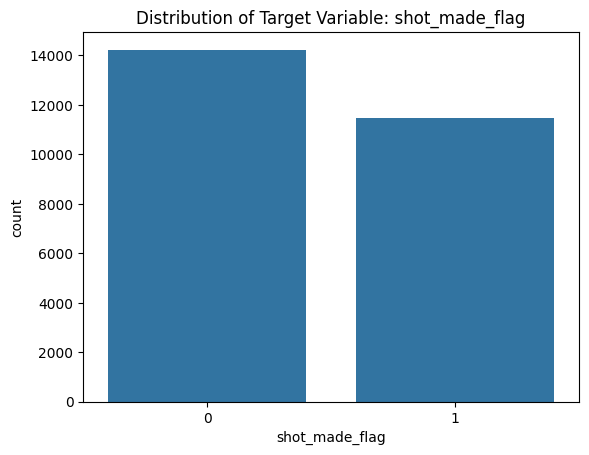

In [10]:
# ✅ Check class balance
sns.countplot(x='shot_made_flag', data=data)
plt.title('Distribution of Target Variable: shot_made_flag')
plt.show()

✅ What it shows:
This tells us how balanced the target variable is:
1 = Shot made
0 = Shot missed
💡 Insights:
If the classes are imbalanced (say 60% missed, 40% made), certain models might be biased.
This helps decide whether we need to apply balancing techniques like SMOTE, or use class weights in modeling.

In [ ]:
# ✅ Numerical Feature: shot_distance
sns.histplot(data['shot_distance'], bins=30, kde=True)
plt.title("Distribution of Shot Distance")
plt.xlabel("Shot Distance")
plt.ylabel("Count")
plt.show()

✅ What it shows:
This plot shows how far most shots were taken from the basket.
💡 Insights:
You may see a peak near 0–10 feet, showing Kobe often took close-range shots (like layups).
A second cluster may appear at 22-25 feet, which are likely 3-point shots.
Long-distance shots (beyond 30 feet) are rare — possibly buzzer beaters or half-court attempts.

Why it matters:
Distance from the basket strongly impacts scoring probability. This helps in modeling and also in suggesting better shot zones.

In [ ]:
# ✅ Categorical Feature: period
sns.countplot(x='period', data=data)
plt.title("Shot Attempts by Game Period")
plt.xlabel("Period (Quarter)")
plt.ylabel("Number of Shots")
plt.show()

✅ What it shows:
This tells you how many shots were taken in each quarter (period).
💡 Insights:
Most games have 4 periods. If you see activity in period 5 or more, that indicates overtime shots.
You’ll likely see more shots in the 1st and 3rd quarters when starters play longer.

Why it matters:
Some players perform differently in clutch or fatigue situations. Later periods might affect shot accuracy.

In [ ]:
# ✅ Minutes Remaining
sns.histplot(data['minutes_remaining'], bins=12)
plt.title("Minutes Remaining Distribution")
plt.show()

✅ What it shows:
This tells us how many shots were taken with X minutes left in the quarter.
💡 Insights:
Spikes around 6–12 minutes are common.
Very few shots happen in the last minute, but those are often high-pressure shots.

Why it matters:
Timing plays a key role in the game. We’ll later combine this with seconds_remaining to create a time_remaining feature.

In [ ]:
# ✅ Seconds Remaining
sns.histplot(data['seconds_remaining'], bins=30)
plt.title("Seconds Remaining Distribution")
plt.show()

✅ What it shows:
This shows the distribution of shots taken during different seconds of a minute.
💡 Insights:
Sharp increase in shots during the last 5 seconds.
These are likely buzzer beaters or end-of-possession shots.

Why it matters:
We can create a clutch_moment feature: when time_remaining <= 5, scoring becomes less probable.

In [ ]:
# ✅ Playoff Distribution
sns.countplot(x='playoffs', data=data)
plt.title("Playoffs (1) vs Regular Season (0)")
plt.show()

✅ What it shows:
This tells how many shots were taken in playoffs (1) vs regular season (0).
💡 Insights:
Majority of shots are from the regular season.
Playoff shots are fewer but often happen in more intense, clutch conditions.

Why it matters:
Players tend to shoot differently under playoff pressure — this feature might influence the shot outcome.

##  Bivariate Analysis

In [ ]:
# ✅ Shot Accuracy vs Distance
sns.boxplot(x='shot_made_flag', y='shot_distance', data=data)
plt.title("Shot Accuracy vs Shot Distance")
plt.xlabel("Shot Made Flag")
plt.ylabel("Shot Distance")
plt.show()

Outlier Analysis: Shot Distance
- We observed several outliers in `shot_distance`, especially for missed shots.
- Most successful shots occur within 30 feet.
- Outliers mostly represent deep 3-pointers or half-court heaves.
- Depending on the model, we may choose to either retain or remove these for optimal performance.

In [ ]:
# Outlier Handling
Q1 = data['shot_distance'].quantile(0.25)
Q3 = data['shot_distance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out extreme outliers
data = data[(data['shot_distance'] >= lower_bound) & (data['shot_distance'] <= upper_bound)]

✅ What it shows:
This boxplot compares the distribution of shot distances for made vs missed shots.
💡 Insights:
Made shots tend to have a lower median distance — makes sense, closer shots are easier.
Missed shots have a wider spread and more long-distance attempts.
Some successful long shots are outliers (possibly buzzer beaters or 3PTs).

Why it matters:
Shot distance is strongly predictive of whether a shot will be made.
This plot justifies keeping shot_distance as an important numerical feature.

In [ ]:
# ✅ Shot Zone vs Outcome
plt.figure(figsize=(12, 6))
sns.countplot(x='shot_zone_area', hue='shot_made_flag', data=data)
plt.title("Shot Zone Area vs Shot Outcome")
plt.xticks(rotation=45)
plt.show()

✅ What it shows:
A stacked countplot showing how many shots were made or missed in each zone area:
Left Side
Right Side
Center
Back Court, etc.
💡 Insights:
Shots from the center area generally have a better success rate.
Backcourt shots (long distance) are rarely made — low percentage.
Right vs Left side may show subtle player preferences.

Why it matters:
shot_zone_area is a categorical feature with location-based insights.
Helps in recommending better zones to shoot from.
May require encoding (e.g., one-hot or label encoding).

In [ ]:
# ✅ Shot Zone Basic
plt.figure(figsize=(12, 6))
sns.countplot(x='shot_zone_basic', hue='shot_made_flag', data=data)
plt.title("Basic Shot Zones vs Shot Outcome")
plt.xticks(rotation=45)
plt.show()

✅ What it shows:
A detailed breakdown of shots in specific basic court zones (like “Restricted Area”, “Mid-Range”, “In The Paint”, “Above the Break 3”, etc.) and whether they were made or missed.
💡 Insights:
Restricted Area (close to the basket) has a very high make rate.
Mid-range has more misses — least efficient in modern basketball.
Corner 3s often show a decent success rate (shortest 3PTs).

Why it matters:
shot_zone_basic is extremely important for feature selection.
Coaches use this insight to discourage mid-range shots and promote efficient zones.

## Heatmap of Shot Locations

In [ ]:
# ✅ KDE Plot of Shot Locations (Court Heatmap)
plt.figure(figsize=(10, 6))
sns.kdeplot(
    x=data['loc_x'],
    y=data['loc_y'],
    fill=True,
    cmap='viridis',
    thresh=0.05
)
plt.title("Heatmap of Shot Locations")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

✅ What This Shows:
High-density areas (brighter/yellow) indicate most frequent shot locations.
You’ll likely see a dense cluster near the basket (layups, dunks).
A second cluster may appear around the 3-point line (especially above the arc).

💡 Insights You Can Mention:
Kobe took a large number of shots in the paint/restricted area.
Significant number of shots from top of the key (3-point arc).
Very few attempts from far corners and backcourt (those are desperation shots).

In [ ]:
# Convert float to int first (0.0/1.0 to 0/1)
data['shot_made_flag'] = data['shot_made_flag'].astype(int)

# Map 0 → 'Missed', 1 → 'Made'
data['shot_result'] = data['shot_made_flag'].map({0: 'Missed', 1: 'Made'})


🧠 Insight:
The original shot_made_flag column contains binary values in float format (0.0 for a missed shot and 1.0 for a made shot). These values are essential for training the model, but not very intuitive when analyzing the data visually or sharing with stakeholders.
✅ Therefore:
First, we convert the column from float to int to ensure clean binary classification (0 or 1).
Then, we map the numeric values to their corresponding labels using a dictionary:
0 → 'Missed'
1 → 'Made'

In [ ]:
#unique data in output column
print(data['shot_result'].unique()) 

In [ ]:
# Made vs Missed Shots
import plotly.express as px

fig = px.scatter(
    data,
    x='loc_x',
    y='loc_y',
    color='shot_result',  # Now categorical
    title='🎯 Kobe Bryant Shot Chart (Made vs Missed)',
    labels={'loc_x': 'Court X', 'loc_y': 'Court Y', 'shot_result': 'Shot Outcome'},
    opacity=0.5,
    color_discrete_map={'Made': 'green', 'Missed': 'red'}  # Optional: nice color scheme
)

fig.update_layout(height=600, width=1000)
fig.show()



✅ What it shows:
This interactive scatter plot is based on court location and shot outcome.
Each dot represents one shot.
Green = Made, Red = Missed.
X/Y axes represent the court layout.
The interactive plot allows you to zoom in, hover, and explore specific regions (e.g., paint, 3-point line, corners).

Key Insights:
🔹 1. High Accuracy in Restricted Area
There is a dense green cluster near the basket (loc_y ≈ 0 to 100).
Kobe had a very high success rate close to the rim — layups, dunks, and short jumpers.
🔹 2. More Misses From Long Distance
As the distance from the basket increases (loc_y > 200), red dots increase.
Long 2s and deep 3s had lower accuracy — expected due to shot difficulty.
🔹 3. Balanced Shooting Behavior
The chart is fairly symmetrical along the X-axis, meaning Kobe shot from both left and right wings regularly.
🔹 4. Fewer Corner Shots
Few points near loc_x = ±220, loc_y < 100 — corners of the court.
Indicates that Kobe preferred center and wing areas over corners.

In [ ]:
Short insight : Kobe’s most efficient zones were close to the basket. Coaches could use this insight to optimize offensive plays that bring him closer to the rim while limiting long 2-point attempts.